TokaMaker Example: Bridging fixed- to free-boundary {#doc_tMaker_fixed_ex2}
==========
In this example we show how to compute a fixed-boundary equilibria using TokaMaker and then compute the necessary currents in a coil set to produce this equilbrium in free-boundary and confirm the validity of these currents using a free-boundary calculation. This demonstrates representative steps required to design coilsets for a new machine with desired plasma configurations.

---

## This version aims at optimizing the poloidal angles of the coils and not the relative distances

## For the $\textbf{free boundary case}$, please refer to fixed_boundary_ex2_DIIID.ipynb in fixed_boundary folder

Equilibria:
$\textbf{(1)}$ g192185.02440 $\textbf{(2)}$ g173630.03000 $\textbf{(3)}$ g174083.03500 $\textbf{(4)}$ g174864.02500 $\textbf{(5)}$ g199085.03500


---

Little recap on $\textbf{TokaMaker()}$ object. Its attributs are:
- mygs = TokaMaker() : initialize a TokaMaker object
- mygs.settings.maxits : sets the maximum non-linear iteration count for G-S solver
- mygs.setup_mesh() : load the mesh from .h5 file
- mygs.setup_regions() : load the region from .h5 file
- mygs.setup() : setup the required solver objects
- mygs.set_coil_vsc() : pair of poloidal field coils for vertical stability in order to help with convergence
- mygs.set_targets() : we define a target for $\textbf{the plasma current}$ and the $\textbf{peak plasma pressure}$ on the magnetic axis
- mygs.set_isoflux() : set points, which are points we want to lie on the same flux surface (eg. the LCFS)
- mygs.set_coil_reg() : Pass regularization terms to TokaMaker
- mygs.set_profiles() : Set the profiles contained in EDQSK file (e.g FF' & PP') in order to solve GS
- mygs.init_psi() : Note that before running a calculation for the first time we must initialize the flux function $\psi$
- mygs.solve() : Solve GS and give equilibrium
- mygs.print_info() : Gives info about the computed equilibrium (e.g Topology, toroidal current, beta, toroidal flux, plasma volume, ...)

On $\textbf{BFGS}$ algo:
- BFGS stops when the |$\nabla$| < $\textit{gtol}$
- Algo sets some relevant solver-specific tolerance(s) equal to $\textit{tol}$

In [1]:
import os
import sys
import json
import copy
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from helper_functions_angle import resize_polygon, place_points, update_boundary, plot_coil
plt.rcParams['figure.figsize']=(6,6)
plt.rcParams['font.weight']='bold'
plt.rcParams['axes.labelweight']='bold'
plt.rcParams['lines.linewidth']=2
plt.rcParams['lines.markeredgewidth']=2
%matplotlib inline
%config InlineBackend.figure_format = "retina"

## Load TokaMaker library

To load the TokaMaker python module we need to tell python where to the module is located. This can be done either through the `PYTHONPATH` environment variable or using within a script using `sys.path.append()` as below, where we look for the environement variable `OFT_ROOTPATH` to provide the path to where the OpenFUSIONToolkit is installed (`/Applications/OFT` on macOS).

For meshing we will use the \ref OpenFUSIONToolkit.TokaMaker.gs_Domain "gs_Domain" class to build a 2D triangular grid suitable for Grad-Shafranov equilibria. This class uses the [triangle code](https://www.cs.cmu.edu/~quake/triangle.html) through a simple internal python wrapper within OFT.

In [2]:
sys.path.append('/Applications/OpenFUSIONToolkit/python')
# tokamaker_python_path = '/home/jerem/tokamaker/OpenFUSIONToolkit/libs/install_release'
# if tokamaker_python_path is not None:
#     sys.path.append(os.path.join(tokamaker_python_path,'python'))
from OpenFUSIONToolkit import OFT_env
from OpenFUSIONToolkit.TokaMaker import TokaMaker
from OpenFUSIONToolkit.TokaMaker.meshing import gs_Domain, save_gs_mesh
from OpenFUSIONToolkit.TokaMaker.util import create_isoflux, read_eqdsk, eval_green
from OpenFUSIONToolkit.util import mu0

## Create mesh
First we define a target size to set the resolution in our grid. This variable will be used later and represent the target edge size within our mesh, where units are in meters. In this case we are using a fairly coarse resolution of 1.5 cm (10 radial points). Note that when setting up a new machine these values will need to scale with the overall size of the device/domain. It is generally a good idea perform a convergence study, by increasing resolution (decreasing target size) by at least a factor of two in all regions, when working with a new geometry to ensure the results are not sensitive to your choice of grid size.

### Define boundary
For this example we will first generate a mesh for fixed-boundary calculation using the simple flux surface definition in \ref OpenFUSIONToolkit.TokaMaker.create_isoflux "create_isoflux". This function parameterizes a surface using a center point (R,Z), minor radius (a), and elongation and triangularity, which can can optionally have different upper and lower value. For this case we make a plasma comparable to those generated in the LTX-$\beta$ device at the Princeton Plasma Physics Laboratory.

In [3]:
# Loading DIII-D LCFS from EQDSK file
mesh_dx = 0.015
eqdsk = read_eqdsk('g192185.02440') # DIII-D shot
LCFS_contour = eqdsk['rzout'].copy()

In [4]:
eqdsk.keys()

dict_keys(['case', 'nr', 'nz', 'rdim', 'zdim', 'rcentr', 'rleft', 'zmid', 'raxis', 'zaxis', 'psimag', 'psibry', 'bcentr', 'ip', 'fpol', 'pres', 'ffprim', 'pprime', 'psirz', 'qpsi', 'nbbs', 'nlim', 'rzout', 'rzlim'])

### Define regions and attributes
We now create the mesh object and define the various logical mesh regions. In this case we only have one region, which is named `plasma` and is of type `plasma`. See other examples for more complex cases with other region types.

In [5]:
# Create a G-S domain
gs_mesh = gs_Domain()
# Define region information for mesh
gs_mesh.define_region('plasma',mesh_dx,'plasma')

### Define geometry for region boundaries
Once the region types and properties are defined we now define the geometry of the mesh using shapes and references to the defined regions.

In [6]:
gs_mesh.add_polygon(LCFS_contour,'plasma')

### Generate mesh
Now we generate the actual mesh using the \ref OpenFUSIONToolkit.TokaMaker.gs_Domain.build_mesh "build_mesh" method. This step may take a few moments as [triangle](https://www.cs.cmu.edu/~quake/triangle.html) generates the mesh.

Note that, as is common with unstructured meshes, the mesh is stored a list of points `mesh_pts` of size (np,2), a list of cells formed from three points each `mesh_lc` of size (nc,3), and an array providing a region id number for each cell `mesh_reg` of size (nc,), which is mapped to the names above using the `coil_dict` and `cond_dict` dictionaries.

In [7]:
mesh_pts, mesh_lc, mesh_reg = gs_mesh.build_mesh()

Assembling regions:
  # of unique points    = 294
  # of unique segments  = 2
Generating mesh:
  # of points  = 9280
  # of cells   = 18264
  # of regions = 1


### Plot resulting regions and grid
We now plot the mesh to inspect proper generation.

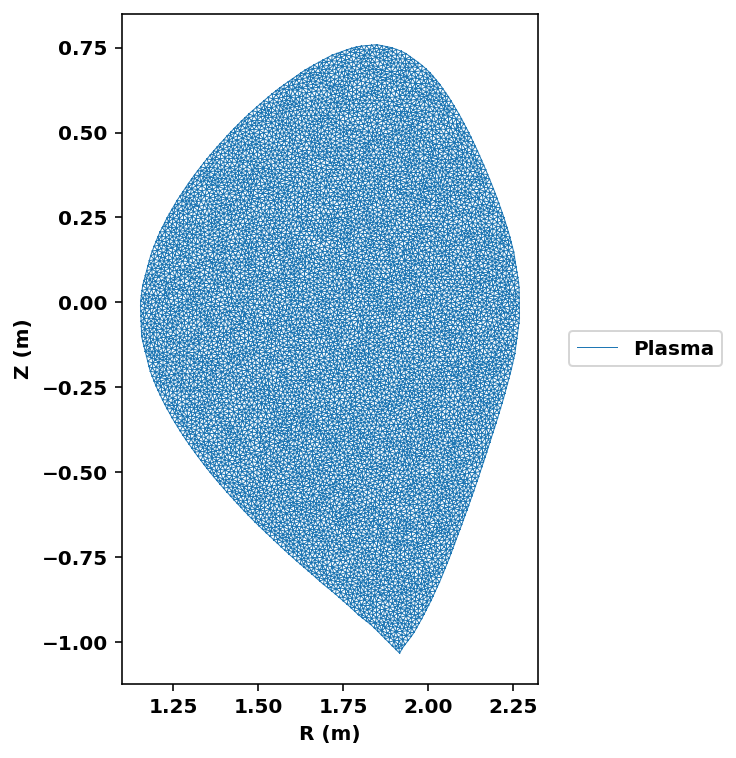

In [8]:
# DIII-D region and grid
fig, ax = plt.subplots(1,1,figsize=(5,8),constrained_layout=True)
gs_mesh.plot_mesh(fig,ax)

## Compute equilibria

### Initialize TokaMaker object
First we create a TokaMaker instance to use for equilibrium calculations. Note at present only a single instance can be used per python kernel, so this command should only be called **once** in a given Jupyter notebook or python script. In the future this restriction may be relaxed.

In [9]:
myOFT = OFT_env(nthreads=2)
mygs = TokaMaker(myOFT)

#----------------------------------------------
Open FUSION Toolkit Initialized
Development branch:   main
Revision id:          77e67da
Parallelization Info:
  Not compiled with MPI
  # of OpenMP threads =    2
Fortran input file    = /var/folders/05/5bk04kj15rg64s4vd1hd6r0m0000gn/T/oft_16834/oftpyin
XML input file        = none
Integer Precisions    =    4   8
Float Precisions      =    4   8  10
Complex Precisions    =    4   8
LA backend            = native
#----------------------------------------------



### Load mesh into TokaMaker
Now we load the mesh generated above using \ref OpenFUSIONToolkit.TokaMaker.TokaMaker.setup_mesh "setup_mesh" and set the code to operate in fixed boundary mode by setting the `free_boundary` setting to False. Finally, we call \ref OpenFUSIONToolkit.TokaMaker.TokaMaker.setup "setup" to setup the required solver objects. During this call we can specify the desired element order (min=2, max=4) and the toroidal field through F0 = B0*R0, where B0 is the toroidal field at a reference location R0.

In [10]:
mygs.setup_mesh(mesh_pts,mesh_lc)
mygs.settings.free_boundary = False
mygs.setup(order=2,F0=0.10752)


**** Loading OFT surface mesh

**** Generating surface grid level  1
  Generating boundary domain linkage
  Mesh statistics:
    Area         =  1.325E+00
    # of points  =    9280
    # of edges   =   27543
    # of cells   =   18264
    # of boundary points =     294
    # of boundary edges  =     294
    # of boundary cells  =     294
  Resolution statistics:
    hmin =  9.309E-03
    hrms =  1.365E-02
    hmax =  2.307E-02
  Surface grounded at vertex       7


**** Creating Lagrange FE space
  Order  =    2
  Minlev =   -1



### Define global quantities and targets
For the Grad-Shafranov solve we define targets for the plasma current and the ratio the F*F' and P' contributions to the plasma current, which is approximately related to $\beta_p$ as Ip_ratio = $1/\beta_p - 1$.

In [11]:
#Ip_target = 120.E3
#Beta_target = 0.5
#mygs.set_targets(Ip=Ip_target,Ip_ratio=(1.0/Beta_target - 1.0))
Ip_target = eqdsk['ip']
pres_target = eqdsk['pres'][0]
mygs.set_targets(Ip=Ip_target, pax=pres_target)

### Initialize the flux function
Before running a calculation for the first time we must initialize the flux function $\psi$, which can be done using \ref OpenFUSIONToolkit.TokaMaker.TokaMaker.init_psi "init_psi". By default this calculation uses a uniform current (equal to Ip_target) over the full plasma domain. Additional options are also availble to tailor this distribution for more control.

In [12]:
err_flag = mygs.init_psi()

### Compute a fixed-boundary equilibrium
Now we can compute an equilibrium in this geometry using the default profiles for F*F' and P' by running \ref OpenFUSIONToolkit.TokaMaker.TokaMaker.solve "solve"

In [13]:
err_flag = mygs.solve()

Starting non-linear GS solver
     1  7.4958E-01  8.5761E-02  3.9810E-04  1.7868E+00 -4.0450E-02  0.0000E+00
     2  9.0890E-01  6.8636E-02  1.2693E-04  1.7821E+00 -4.0411E-02  0.0000E+00
     3  9.4714E-01  6.4809E-02  4.5446E-05  1.7796E+00 -4.0323E-02  0.0000E+00
     4  9.5804E-01  6.3765E-02  1.7289E-05  1.7784E+00 -4.0249E-02  0.0000E+00
     5  9.6136E-01  6.3458E-02  6.7274E-06  1.7780E+00 -4.0199E-02  0.0000E+00
     6  9.6241E-01  6.3363E-02  2.6307E-06  1.7778E+00 -4.0170E-02  0.0000E+00
     7  9.6275E-01  6.3333E-02  1.0278E-06  1.7777E+00 -4.0155E-02  0.0000E+00
     8  9.6286E-01  6.3323E-02  4.0084E-07  1.7776E+00 -4.0147E-02  0.0000E+00
 Timing:  0.31017399998381734     
   Source:    0.17684400003054179     
   Solve:      9.3440999975427985E-002
   Boundary:   5.3400000324472785E-003
   Other:      3.4548999945400283E-002


### Print information and plot equilibrium
After computing the equilibrium, basic parameters can be displayed using the \ref OpenFUSIONToolkit.TokaMaker.TokaMaker.print_info "print_info" method. For access to these quantities as variables instead the \ref OpenFUSIONToolkit.TokaMaker.TokaMaker.get_stats "get_stats" can be used.

Flux surfaces can be plotted using the \ref OpenFUSIONToolkit.TokaMaker.TokaMaker.plot_psi "plot_psi" method. Additional plotting methods are also available to display other information for more complex cases. See other examples and the documentation for more information.

Equilibrium Statistics:
  Topology                =   Limited
  Toroidal Current [A]    =    4.9332E+05
  Current Centroid [m]    =    1.737 -0.051
  Magnetic Axis [m]       =    1.778 -0.040
  Elongation              =    1.608 (U:  1.433, L:  1.784)
  Triangularity           =   -0.301 (U: -0.244, L: -0.358)
  Plasma Volume [m^3]     =   14.542
  q_0, q_95               =    0.323  0.193
  Peak Pressure [Pa]      =    6.8215E+03
  Stored Energy [J]       =    5.1004E+04
  <Beta_pol> [%]          =   30.1985
  <Beta_tor> [%]          =   148.8870
  <Beta_n>   [%]          =   10.5646
  Diamagnetic flux [Wb]   =    8.7056E-02
  Toroidal flux [Wb]      =    1.7072E-01
  l_i                     =    0.8102


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


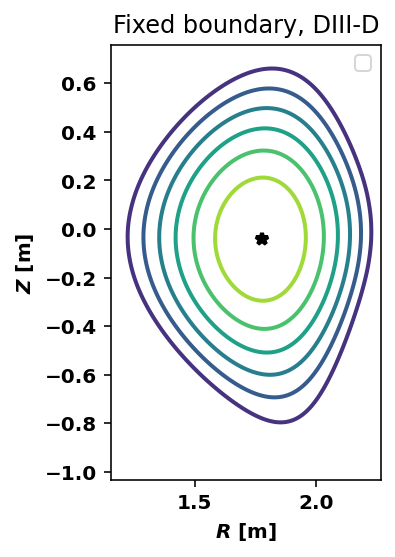

In [14]:
mygs.print_info()
# Plot flux surfaces
fig, ax = plt.subplots(1,1)
mygs.plot_psi(fig,ax)
plt.xlabel('$R$ [m]')
plt.ylabel('$Z$ [m]')
plt.title('Fixed boundary, DIII-D')
plt.legend()

In [15]:
# will be one of the targets for the free-boundary case
fixed_mag_axis = mygs.o_point.copy()

Computing fixed boundary vacuum flux
 Computing flux BC matrix 
 Inverting real matrix
   Time =    2.5124000000000000E-002
 Starting LU solver: umfpack T


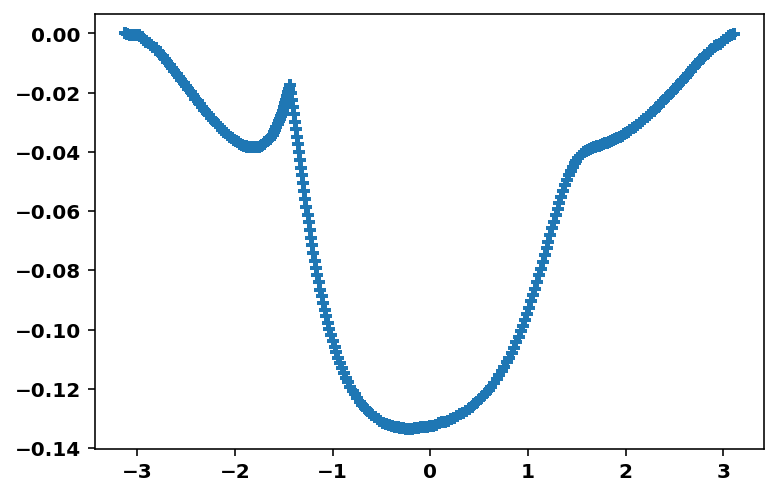

In [16]:
r_bnd, psi_bnd = mygs.get_vfixed()
# Plot required relative flux on boundary
fig, ax = plt.subplots()
theta = np.arctan2(r_bnd[:,1],r_bnd[:,0]-mygs.o_point[0])
_=ax.plot(theta[1:],psi_bnd[1:]-psi_bnd[0],'+')

-----

## Optimization process

The objective function optimizes coil locations by iteratively adjusting their positions to minimize the cost value after having obtained the optimized currents

loading DIII-D shot & geometry

In [17]:
eqdsk = read_eqdsk('g192185.02440') # shot
with open('DIIID_geom.json','r') as fid: # geometry
    DIIID_geom = json.load(fid)

Setting grid resolutions

In [18]:
plasma_dx = 0.04
coil_dx = 0.03
vv_dx = 0.04
vac_dx = 0.10

Define the limiter & coil possible locations

In [19]:
# Get the limiter (plasma boundary)
lim0 = np.array(DIIID_geom['limiter'])
lim = update_boundary(r0=1.69, z0=0, a0=0.67, kappa=2, delta=0.8, squar=0.15, npts=400) # generates a modified limiter with parameters (npts is initially 201)
                                                                                        # return a list of (R,Z) coord of plasma bound.
# coil_centers_cand contains 400 candidate positions
coil_center_cand = resize_polygon(lim, 0.3) # scales the arc outward or inward

In [20]:
# make_new_coils() generates new coil locations
# Creates rectangular coils at these locations
#           -> Each coil has an "A" (top) and "B" (bottom) pair for symmetry
#           -> Each coil is assigned 1 turn (nturns=1.0), one loop of current
## ACTUAL #################
def make_new_coils(
        nCoils, 
        pol_angles, 
        dx=0.08, 
        dy=0.08,
        ifplot=True,
        distribution2=None  # allow plotting a second distib
):
    """
    Generates and places new poloidal field (PF) coils given their poloidal angles 
    along a plasma boundary. It creates a set of coil pairs (one above and one 
    below the midplane). Optionally plots the first configuration, and if a 
    second distribution is given, it plots both.

    Parameters:
        - nCoils: Number of coils
        - pol_angles: List of poloidal angles (degrees)
        - dx: Horizontal coil size
        - dy: Vertical coil size
        - ifplot: Boolean, whether to plot the coils
        - distribution2: (Optional) second list of poloidal angles

    Returns:
        scan_geom (dictionary)
    """
    #print("nb of coils nCoils as input in make_new_coils", nCoils)
    scan_geom = {}
    scan_geom["coils"] = {}
    
    # Defining coil locations for the first distribution (2nd arg is just the top-side of coil_center_cand)
    inds, locs = place_points(nCoils, coil_center_cand[:len(coil_center_cand)//2,:], pol_angles)

    # Creating coil pairs for (1st) distribution
    for i, loc in enumerate(locs):
        pts_top = np.array([[loc[0]-dx, loc[1]+dy], [loc[0]+dx, loc[1]+dy], 
                            [loc[0]+dx, loc[1]-dy], [loc[0]-dx, loc[1]-dy]])
        pts_bot = pts_top * np.array([1, -1])

        # Storing coils
        scan_geom["coils"][f'F{i}A'] = {'pts': copy.deepcopy(pts_top), 'nturns': 1.0}
        scan_geom["coils"][f'F{i}B'] = {'pts': copy.deepcopy(pts_bot), 'nturns': 1.0}

    if ifplot:
        # Make the figure
        plt.figure(figsize=(6, 10))
        ax = plt.subplot(111)
        ax.axis('equal')

        # Plot the limiter
        plt.plot(np.hstack((lim0[:, 0], lim0[0, 0])), np.hstack((lim0[:, 1], lim0[0, 1])), c='k')
        plt.plot(lim[:, 0], lim[:, 1], c='k', ls=':')

        # Plot the first set of coils
        for coil in scan_geom["coils"]:
            if 'ECOIL' not in coil:
                pts = np.array(scan_geom["coils"][coil]['pts'])
                plot_coil(pts, ax) 
                plt.text(np.average(pts[:, 0]), np.average(pts[:, 1]), coil, ha='center', va='center')

        # If provided, plot the (2nd) distrib
        if distribution2 is not None:
            scan_geom_2 = {}
            scan_geom_2["coils"] = {}
            inds2, locs2 = place_points(nCoils, coil_center_cand[:len(coil_center_cand)//2, :], distribution2)

            for i, loc in enumerate(locs2):
                pts_top2 = np.array([[loc[0]-dx, loc[1]+dy], [loc[0]+dx, loc[1]+dy], 
                                     [loc[0]+dx, loc[1]-dy], [loc[0]-dx, loc[1]-dy]])
                pts_bot2 = pts_top2 * np.array([1, -1])

                # Storing second set of coils, oF -> just name for optimized distrib
                scan_geom_2["coils"][f'oF{i}A'] = {'pts': copy.deepcopy(pts_top2), 'nturns': 1.0}
                scan_geom_2["coils"][f'oF{i}B'] = {'pts': copy.deepcopy(pts_bot2), 'nturns': 1.0}

            # Plot the second set of coils in a different color (e.g., red)
            for coil in scan_geom_2["coils"]:
                if 'ECOIL' not in coil:
                    pts2 = np.array(scan_geom_2["coils"][coil]['pts'])
                    plot_coil(pts2, ax)  
                    ax.plot(pts2[:, 0], pts2[:, 1], 'r')
                    plt.text(np.average(pts2[:, 0]), np.average(pts2[:, 1]), coil, ha='center', va='center', color='r')

        ax.set_xlabel('R (m)')
        ax.set_ylabel('Z (m)')

    #print(f"Total coils generated: {len(scan_geom['coils'])}")

    return scan_geom


In [21]:
# Function to compute the cost given coil currents (from fixed_boundary_ex2)
# Define objective function
## ACTUAL ####################
def cost_fct(curr, G, psi_bnd):
    """
    Computes the squared error between the desired boundary flux and the one produced by the coils
    
    Arguments:
    - curr: Array of coil currents guess (to be optimized)
    - G: Green matrix 
    - psi_bnd: Target boundary flux values
    
    Returns:
    - cost function : scalar error squared plus regularization to be minimized
    """
    lambda_reg = 1e-12 # regularization parameter (opt is 1e-12)
    flux_pred = np.zeros(psi_bnd.shape[0])
    
    # Compute total flux from all coils 
    flux_pred = np.dot(G,curr)

    # Squared error between predicted and target flux
    scal = 10e4 # scaling factor
    error = np.sum(((flux_pred - psi_bnd)/(np.mean(psi_bnd)))**2)*scal
    L2_reg = lambda_reg * np.sum(curr**2) # L2 regularizer
    
    return error + L2_reg

In [22]:
def compute_coil_centers(scan_geom):
    """
    Compute the center of each coils (squares)

    Parameter: - scan_geom: dict with coils informations
    return:    - coil_centers: coils centers (2D array, (R,Z) position)
    """
    coil_centers = []

    # Loading and computing the mean of coil edges for each coil
    for i, coil in enumerate(scan_geom["coils"]):
        pts = np.array(scan_geom["coils"][coil]["pts"])
        center = np.mean(pts, axis=0) # mean along column

        # Store the center as a pair (for a single coil)
        coil_centers.append(np.asarray([center]))  # Each element is a 2D array with one center

    return coil_centers

In [23]:
# Function to compute the cost given coil currents (from fixed_boundary_ex2)
# Function to optimize coil positions

def opt_current(init_angles, scan=False, plot_err=False):
    """
    Optimizes the coil locations by minimizing the obective function
    
    This function updates coil positions by solving for the best coil 
    currents at each step and adjusting positions accordingly.

    Arguments:
    - init_angles: Initial list of poloidal angles (degrees) for coil positions
    - scan: if True, return also the final cost (useful if we perform a parameter scan on opt_coil_loc and 
                                                and are interested for the lowest value)
    - plot_err: if True, plot the error w.r.t to the current optimization (inner loop)
    Returns:
    - Optimized coil positions as an array of poloidal angles (degrees)
    """
    # Number of coils in the upper part (x2 with symmetry)
    num_coils = len(init_angles)
    final_currs = None  # Store final coil currents
    final_con = None    # Store final con matrix
    final_inner_cost = None 

    #print(f"Current coil distrib: {init_distr}")
    #num_coils = len(init_distr)-1 # without the symmetry
    # Loading new coil configuration (name, positions, etc)
    scan_geom_DIIID = make_new_coils(num_coils, init_angles, ifplot=False)
    # compute coil centers
    new_coil_center = compute_coil_centers(scan_geom_DIIID)
    # Find the best currents for a given coil conf
    #def cost_currents(currents):
    #    return cost_fct(currents, new_coil_center, r_bnd, psi_bnd)
    #print(f"New coil centers: {new_coil_center}") 
    # Initial guess for currents
    initial_curr = np.ones(2*num_coils) # with symmetry (when using BFGS)

    ## Least squares method #########################         
    con = np.zeros((psi_bnd.shape[0]+len(new_coil_center)-1, len(new_coil_center)))
    #print("con matrix shape: ", np.shape(con))
    for i, coil_set in enumerate(new_coil_center):
        flux_tmp = np.zeros((psi_bnd.shape[0],))
        for coil in coil_set:
            flux_tmp += eval_green(r_bnd,coil)
        con[:psi_bnd.shape[0]-1,i] = flux_tmp[1:] - flux_tmp[0]
        con[psi_bnd.shape[0]-1+i,i] = 1.E-9 # Regularization term
    # Perform least-squares fit
    err = np.zeros((psi_bnd.shape[0]+len(new_coil_center)-1,))
    err[:psi_bnd.shape[0]-1] = psi_bnd[1:] - psi_bnd[0]
    currs, final_cost, _, _ = np.linalg.lstsq(con, err, rcond=None)
    print("final cost inner loop: ", final_cost[0])

    final_currs = currs  # Store the final currents
    final_con = con      # Store the final con matrix

    #print("Final cost inner loop:", final_cost[0])
    final_inner_cost = final_cost[0].copy()
        
    #################################################

    """
    ## BFGS #####################################

    # compute the green matrix
    G = np.zeros((psi_bnd.shape[0],len(new_coil_center)))
    for i, coil_set in enumerate(new_coil_center):
        for coil in coil_set:
            #flux_pred += curr[i] * eval_green(r_bnd, coil) # as [eval_green] = [psi_unit / A]
            G[:,i] += eval_green(r_bnd, coil)

    # Optimize coil currents for the given coil positions
    result_curr = minimize(cost_fct, initial_curr, args=(G, psi_bnd), method='BFGS', options={'maxiter': 100})
    print("number of iterations inner: ", result_curr.nit)
    print("inner cost: ", result_curr.fun)
    # If optimization was successful, return the minimized cost
    #if result.success:
    return result_curr.fun  # The minimized cost function value
    #else:
    #    raise ValueError("optimization not successful") 

    ###############################################
    """
    
    if plot_err == True:
        # Ensure final_con is not None before plotting
        if final_con is not None and final_currs is not None:
            fig, ax = plt.subplots()
            ax.plot(theta[1:], psi_bnd[1:] - psi_bnd[0], 'o', label="Boundary flux")
            ax.plot(theta[1:], np.dot(final_con, final_currs)[:psi_bnd.shape[0] - 1], '+', label="Computed Flux")
            ax.set_xlabel("Theta")
            ax.set_ylabel("Flux Difference")
            ax.legend()
            plt.show()

    return final_inner_cost

In [24]:
# Function to compute the cost given coil currents (from fixed_boundary_ex2)
# Function to optimize coil positions

def opt_coil_loc(init_angles, scan=False, plot_err=False):
    """
    Optimizes the coil locations by minimizing the obective function
    
    This function updates coil positions by solving for the best coil 
    currents at each step and adjusting positions accordingly.

    Arguments:
    - init_angles: Initial list of poloidal angles (degrees) for coil positions
    - scan: if True, return also the final cost (useful if we perform a parameter scan on opt_coil_loc and 
                                                and are interested for the lowest value)
    - plot_err: if True, plot the error w.r.t to the current optimization (inner loop)
    
    Returns:
    - Optimized coil positions as an array of poloidal angles (degrees)
    """
    # Number of coils in the upper part (x2 with symmetry)
    num_coils = len(init_angles)
    final_currs = None  # Store final coil currents
    final_con = None    # Store final con matrix
    final_inner_cost = None 

    def objective(init_angles):
        """
        Objective function for optimizing coil locations
        
        It first determines the best coil currents for a given coil config, 
        then returns the corresponding cost
        
        Arguments:
        - poloidal_angles: List of poloidal angles for coil positions
        
        Returns:
        - Cost function value based on optimal currents for these positions
        """
        nonlocal final_currs, final_con, final_inner_cost 
        #print(f"Current coil distrib: {init_distr}")
        #num_coils = len(init_distr)-1 # without the symmetry
        # Loading new coil configuration (name, positions, etc)
        scan_geom_DIIID = make_new_coils(num_coils, init_angles, ifplot=False)
        # compute coil centers
        new_coil_center = compute_coil_centers(scan_geom_DIIID)
        # Find the best currents for a given coil conf
        #def cost_currents(currents):
        #    return cost_fct(currents, new_coil_center, r_bnd, psi_bnd)
        #print(f"New coil centers: {new_coil_center}") 
        # Initial guess for currents
        initial_curr = np.ones(2*num_coils) # with symmetry (when using BFGS)

        ## Least squares method #########################         
        con = np.zeros((psi_bnd.shape[0]+len(new_coil_center)-1, len(new_coil_center)))
        #print("con matrix shape: ", np.shape(con))
        for i, coil_set in enumerate(new_coil_center):
            flux_tmp = np.zeros((psi_bnd.shape[0],))
            for coil in coil_set:
                flux_tmp += eval_green(r_bnd,coil)
            con[:psi_bnd.shape[0]-1,i] = flux_tmp[1:] - flux_tmp[0]
            con[psi_bnd.shape[0]-1+i,i] = 1.E-9 # Regularization term
        # Perform least-squares fit
        err = np.zeros((psi_bnd.shape[0]+len(new_coil_center)-1,))
        err[:psi_bnd.shape[0]-1] = psi_bnd[1:] - psi_bnd[0]
        currs, final_cost, _, _ = np.linalg.lstsq(con, err, rcond=None)
        #print("final cost inner loop: ", final_cost[0])

        final_currs = currs  # Store the final currents
        final_con = con      # Store the final con matrix

        #print("Final cost inner loop:", final_cost[0])
        final_inner_cost = final_cost[0].copy()

        return final_cost[0]
        
        #################################################

        """
        ## BFGS #####################################

        # compute the green matrix
        G = np.zeros((psi_bnd.shape[0],len(new_coil_center)))
        for i, coil_set in enumerate(new_coil_center):
            for coil in coil_set:
                #flux_pred += curr[i] * eval_green(r_bnd, coil) # as [eval_green] = [psi_unit / A]
                G[:,i] += eval_green(r_bnd, coil)

        # Optimize coil currents for the given coil positions
        result_curr = minimize(cost_fct, initial_curr, args=(G, psi_bnd), method='BFGS', options={'maxiter': 100})
        print("number of iterations inner: ", result_curr.nit)
        print("inner cost: ", result_curr.fun)
        # If optimization was successful, return the minimized cost
        #if result.success:
        return result_curr.fun  # The minimized cost function value
        #else:
        #    raise ValueError("optimization not successful") 

        ###############################################
        """
    
    # Run the optimization for coil positions
    #return objective(init_distr)
    result = minimize(objective, init_angles, method='Powell', tol = 1e-12, options={'disp': True})

    if plot_err == True:
        # Ensure final_con is not None before plotting
        if final_con is not None and final_currs is not None:
            fig, ax = plt.subplots()
            ax.plot(theta[1:], psi_bnd[1:] - psi_bnd[0], 'o', label="Boundary flux")
            ax.plot(theta[1:], np.dot(final_con, final_currs)[:psi_bnd.shape[0] - 1], '+', label="Computed Flux")
            ax.set_xlabel("Theta")
            ax.set_ylabel("Flux Difference")
            ax.legend()
            plt.show()
    
    print("outer cost: ", result.fun)
    print("number of iterations outer: ", result.nit)
    print("success: ", result.success)
    print("status: ", result.status)
    print("message: ", result.message)

    if scan is True:
        return result.x, result.fun, final_currs, final_inner_cost
    else:
        # Optimized distribution
        return result.x, final_currs

Optimization terminated successfully.
         Current function value: 0.000020
         Iterations: 8
         Function evaluations: 1636


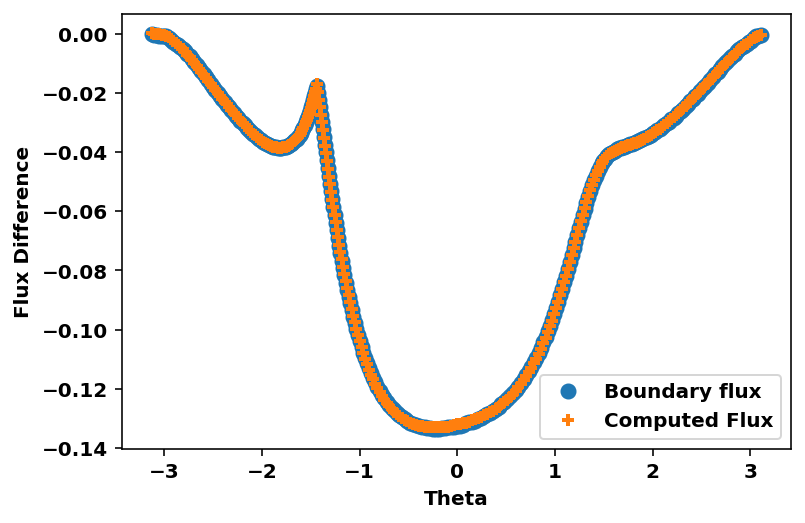

outer cost:  2.0292248029643368e-05
number of iterations outer:  8
success:  True
status:  0
message:  Optimization terminated successfully.
Optimized poloidal angles:  [ 15.75860214  41.55528876  65.54824806 100.17550699 180.        ]


In [25]:
# Compute the optimized poloidal angles for a simple case
initial_pol = [0, 45, 90, 135, 180]
opt_pol, final_outer_cost_pol, final_currs_pol, final_inner_cost_pol = opt_coil_loc(initial_pol, scan=True, plot_err=True)
print("Optimized poloidal angles: ", opt_pol)

{'coils': {'F0A': {'pts': array([[ 2.58000693,  0.08      ],
          [ 2.74000693,  0.08      ],
          [ 2.74000693, -0.08      ],
          [ 2.58000693, -0.08      ]]),
   'nturns': 1.0},
  'F0B': {'pts': array([[ 2.58000693, -0.08      ],
          [ 2.74000693, -0.08      ],
          [ 2.74000693,  0.08      ],
          [ 2.58000693,  0.08      ]]),
   'nturns': 1.0},
  'F1A': {'pts': array([[2.04138241, 1.3912501 ],
          [2.20138241, 1.3912501 ],
          [2.20138241, 1.2312501 ],
          [2.04138241, 1.2312501 ]]),
   'nturns': 1.0},
  'F1B': {'pts': array([[ 2.04138241, -1.3912501 ],
          [ 2.20138241, -1.3912501 ],
          [ 2.20138241, -1.2312501 ],
          [ 2.04138241, -1.2312501 ]]),
   'nturns': 1.0},
  'F2A': {'pts': array([[1.14396301, 1.71988837],
          [1.30396301, 1.71988837],
          [1.30396301, 1.55988837],
          [1.14396301, 1.55988837]]),
   'nturns': 1.0},
  'F2B': {'pts': array([[ 1.14396301, -1.71988837],
          [ 1.303963

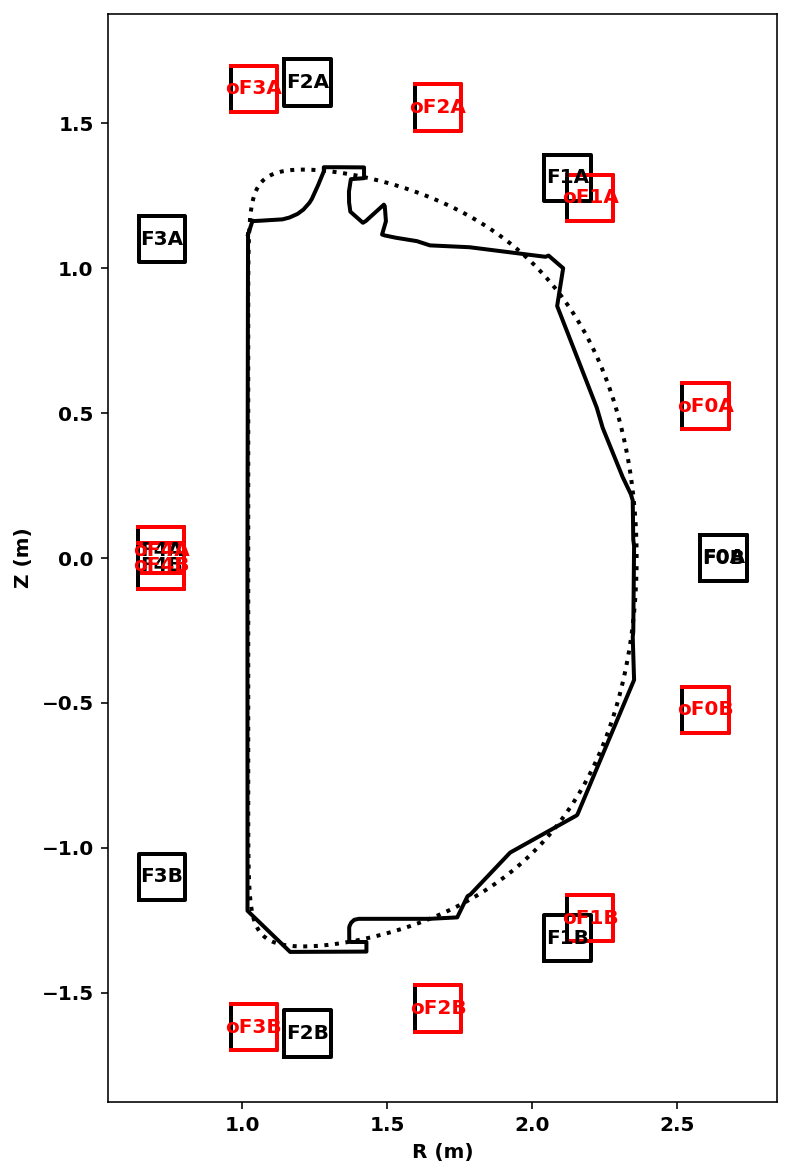

In [26]:
# Plot the optimized coil locations (i.e with optimized poloidal angles)
make_new_coils(len(opt_pol), pol_angles=initial_pol, distribution2=opt_pol)

----

## Compute free-boundary solution with new coils
To show demonstrate the result we now compute a free-boundary equilibrium with the coil currents computed in the previous step. This will use a simple rectangular domain for the plasma, which we will design to limit on the outboard surface at the same location as the fixed-boundary case above.

### Set mesh resolution for each region
First we define some target sizes to set the resolution in our free-boundary grid. These variables will be used later and represent the target edge size within a given region, where units are in meters. Because we used filament coils above we will use small square coils (1 cm x 1 cm), so a high resolution is used in the coil regions.

In [27]:
plasma_dx = 0.01
coil_dx = 0.005
vac_dx = 0.06

### Define regions and attributes
We now create and define the various logical mesh regions. In this case we have three regions:
 - `air`: The region outside the limiter, which is treated like a vacuum
 - `plasma`: The region inside the limiter where the plasma will exist
 - `PF_I_J,...`: Each of the j coils in the i coil sets defined above

For each region we provide a target size and specify the region type:
 - `plasma`: The region where the plasma can exist and the classic Grad-Shafranov equation with $F*F'$ and $P'$ are allowed. **There can only be one region of this type**
 - `boundary`: A special case of the `vacuum` region, which forms the outer boundary of the computational domain. **A region of this type is required if more than one region is specified**
 - `coil`: A region where toroidal current can flow with specified amplitude through \ref OpenFUSIONToolkit.TokaMaker.TokaMaker.set_coil_currents

In [28]:
initial_pol_test = [10, 60, 120]
opt_pol_test, final_currs_pol_test = opt_coil_loc(initial_pol_test)
scan_geom_DIIID_test = make_new_coils(3, opt_pol_test, ifplot=False)
new_coil_center_test = compute_coil_centers(scan_geom_DIIID_test)

Optimization terminated successfully.
         Current function value: 0.000061
         Iterations: 5
         Function evaluations: 667
outer cost:  6.141507877446176e-05
number of iterations outer:  5
success:  True
status:  0
message:  Optimization terminated successfully.


### Define geometry for region boundaries
Once the region types and properties are defined we now define the geometry of the mesh using shapes and references to the defined regions.
 1. We add the limiter contour as a "rectangle", referencing `plasma` as the region enclosed by the contour and `air` as the region outside the contour.
 2. We add each of the coils in the 7 coil sets as "rectangles", which are defined by a center point (R,Z) along with a width (W) and height (H). We also reference `air` as the region outside the coils.

### Plot topology
After defining the logical and physical topology we can now plot the curves within the definitions to double check everything is in the right place.

### Create mesh
Now we generate the actual mesh using the \ref OpenFUSIONToolkit.TokaMaker.gs_Domain.build_mesh "build_mesh" method. Additionally, if `coil` and/or `conductor` regions are defined the \ref OpenFUSIONToolkit.TokaMaker.gs_Domain.get_coils "get_coils" and \ref OpenFUSIONToolkit.TokaMaker.gs_Domain.get_conductors "get_conductors" methods should also be called to get descriptive dictionaries for later use in TokaMaker. This step may take a few moments as [triangle](https://www.cs.cmu.edu/~quake/triangle.html) generates the mesh.

Note that, as is common with unstructured meshes, the mesh is stored a list of points `mesh_pts` of size (np,2), a list of cells formed from three points each `mesh_lc` of size (nc,3), and an array providing a region id number for each cell `mesh_reg` of size (nc,), which is mapped to the names above using the `coil_dict` and `cond_dict` dictionaries.

### Plot resulting regions and grid
We now plot the mesh by region to inspect proper generation.

In [29]:
# Creates a Grad-Shafranov (GS) mesh domain for the magnetic equilibrium
def make_mesh(
        DIIID_geom,
        scan_geom,
        savename = 'DIIID_mesh_scantest.h5',
        ifplot = True
):
    # Create a G-S domain
    gs_mesh = gs_Domain()
    # Define region information for mesh
    gs_mesh.define_region('air',vac_dx,'boundary')                     # Define the bounding region
    gs_mesh.define_region('plasma',plasma_dx,'plasma')                 # Define the plasma region and resolution
    gs_mesh.define_region('vacuum',vv_dx,'vacuum',allow_xpoints=True)  # Define the vacuum inside the VV
    gs_mesh.define_region('vv',vv_dx,'conductor',eta=6e-07)            # Define one region for VV 

    # Define each of the PF coils
    for key, coil in scan_geom["coils"].items():
        if key.startswith('ECOIL'):
            for i, subcoil in enumerate(coil):
                gs_mesh.define_region('{0}_{1}'.format(key,i),coil_dx,'coil',coil_set=key,nTurns=subcoil["nturns"])
        else:
            gs_mesh.define_region(key,coil_dx,'coil',nTurns=coil["nturns"])

    # Define geometry, using the fake limiter
    gs_mesh.add_polygon(lim,'plasma',parent_name='vacuum') 
    gs_mesh.add_annulus(resize_polygon(lim, 0.01),'vacuum',resize_polygon(lim, 0.05),'vv')
    
    gs_mesh.add_enclosed([1.75,1.25],'vacuum')

    # Define each of the PF coils
    for key, coil in scan_geom["coils"].items():
        gs_mesh.add_polygon(coil["pts"],key,parent_name='air')

    # Create mesh
    mesh_pts, mesh_lc, mesh_reg = gs_mesh.build_mesh()
    coil_dict = gs_mesh.get_coils()
    cond_dict = gs_mesh.get_conductors()

    # Plot result
    if ifplot:
        fig, ax = plt.subplots(2,2,figsize=(8,8),constrained_layout=True)
        gs_mesh.plot_mesh(fig,ax)

    # Save mesh for later use
    save_gs_mesh(mesh_pts,mesh_lc,mesh_reg,coil_dict,cond_dict,savename) # Save G-S mesh to file in HDF5 format (.h5)

    return coil_dict, cond_dict

Assembling regions:
  # of unique points    = 2028
  # of unique segments  = 31
Generating mesh:
  # of points  = 61052
  # of cells   = 121874
  # of regions = 10


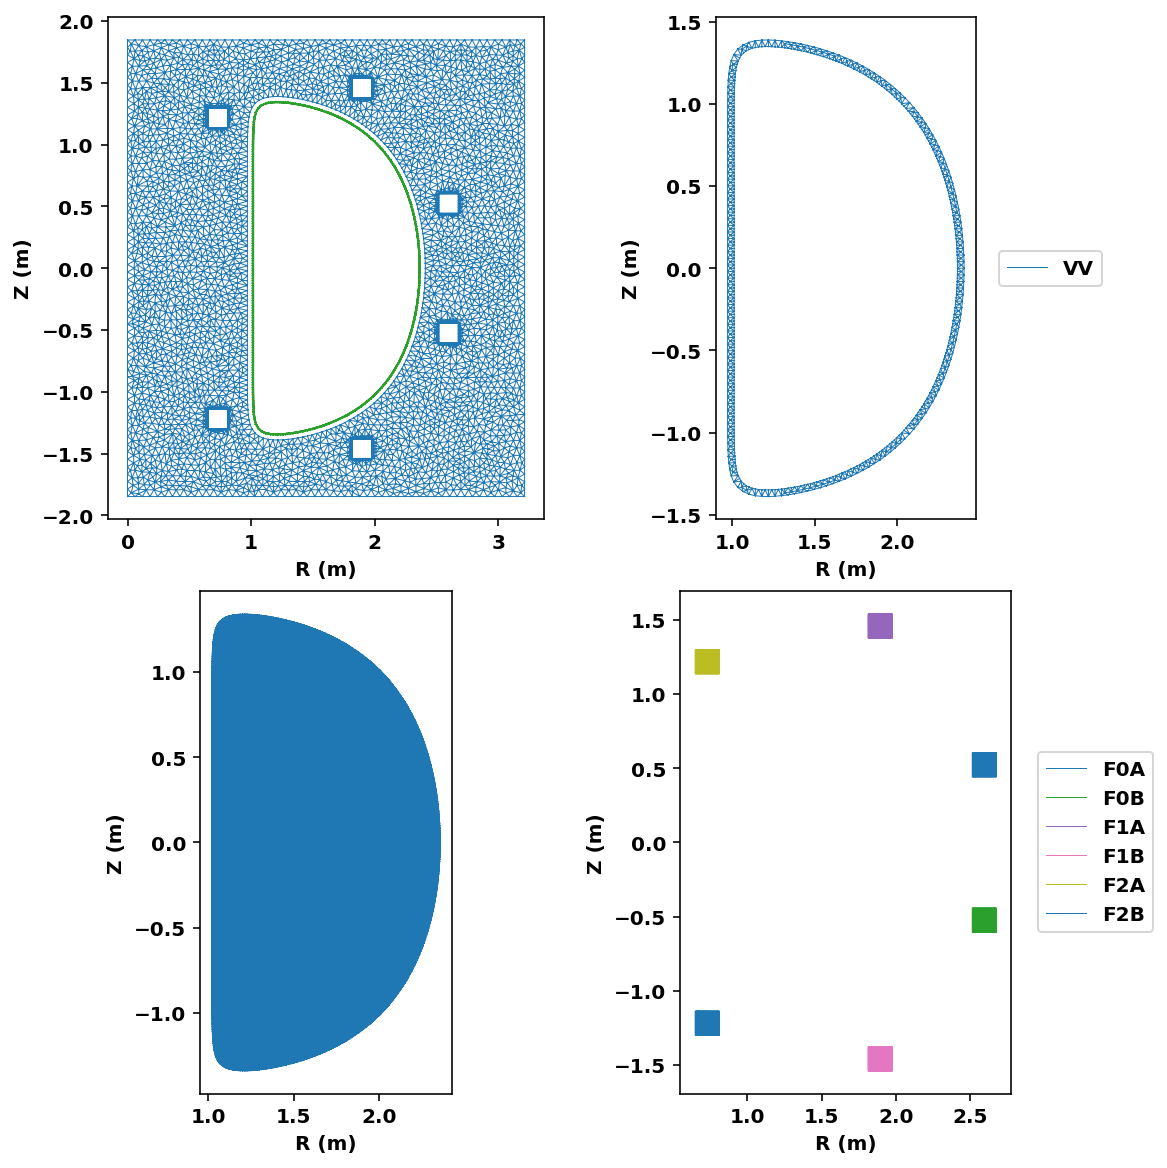

In [30]:
coil_dict, cond_dict = make_mesh(DIIID_geom, scan_geom_DIIID_test)

### Update mesh in TokaMaker
As in \ref doc_tMaker_fixed_ex1 we clear the prior representation and prepare TokaMaker to accept a new configuration. Then we load in the new mesh as above, but we now use \ref OpenFUSIONToolkit.TokaMaker.TokaMaker.setup_regions "setup_regions" to define the different region types. Additionally, we set this run as free-boundary.

In [31]:
from OpenFUSIONToolkit.TokaMaker.meshing import load_gs_mesh

In [32]:
mygs.reset()
mesh_pts, mesh_lc, mesh_reg, coil_dict, cond_dict = load_gs_mesh('DIIID_mesh_scantest.h5') # add this line to access mesh_pts etc
mygs.setup_mesh(mesh_pts,mesh_lc,mesh_reg)
mygs.setup_regions(cond_dict=cond_dict,coil_dict=coil_dict)
mygs.settings.free_boundary = True # free boundary
mygs.setup(order=2,F0=0.10752) # F0: vacuum F value


**** Loading OFT surface mesh

**** Generating surface grid level  1
  Generating boundary domain linkage
  Mesh statistics:
    Area         =  1.187E+01
    # of points  =   61052
    # of edges   =  182925
    # of cells   =  121874
    # of boundary points =     228
    # of boundary edges  =     228
    # of boundary cells  =     228
  Resolution statistics:
    hmin =  3.104E-03
    hrms =  1.588E-02
    hmax =  9.139E-02
  Surface grounded at vertex    1998


**** Creating Lagrange FE space
  Order  =    2
  Minlev =   -1

 Computing flux BC matrix 
 Inverting real matrix
   Time =    1.2463000000000000E-002


### Define a vertical stability coil
The equilibrium we are trying to compute is slightly vertically unstable. So we define a pair of coils, and corresponding polarities, that will be used to control the vertical position in the equilibrium solve. In this case we use the first coil set.

In [33]:
mygs.set_coil_vsc({'F0A': 1.0, 'F0B': -1.0})

### Set coil currents
We now set the current in each coil to the currents computed by the least-square fit above. This is done using the \ref OpenFUSIONToolkit.TokaMaker.TokaMaker.set_coil_currents "set_coil_currents" method, where currents are given in the total number of Amps flowing in the coil (also known as Amp-turns). The current is the same in each coil of a given coil set. Additionally, the current needs to be in the opposite direction as above.

In [34]:
final_currs_pol_test

array([ 132455.3751354 ,  152949.37908964, -146603.59015402,
       -146610.4245373 ,  906874.01778719,  916237.76955855])

In [35]:
new_coil_currents = {}
coil_names = mygs.coil_sets.keys()
coil_names = list(coil_names)

for i, coil in enumerate(coil_names):
    print(i, " ", coil)
    new_coil_currents[coil] = -final_currs_pol_test[i]

mygs.set_coil_currents(new_coil_currents)

0   F0A
1   F0B
2   F1A
3   F1B
4   F2A
5   F2B


### Define global quantities and targets
Again we define a target for the plasma current, but instead of a target Ip_ratio we target the radial and vertical position of $\textbf{on the magnetic axis}$ from the fixed boundary calculation above. The radial position is used to control the plasma pressure and the vertical position is used along with the VSC above to keep the plasma centered.

In [36]:
Ip_target = eqdsk['ip']
R0_target = fixed_mag_axis[0].item()
Z0 = fixed_mag_axis[1].item()
mygs.set_targets(Ip=Ip_target,R0=R0_target,V0=Z0)

### Define hard limits on coil currents

coil_bounds = {key: [-6.E8, 6.E8] for key in mygs.coil_sets}
mygs.set_coil_bounds(coil_bounds)

### Compute a free-boundary equilibrium
Now we can compute a free-boundary equilibrium for comparison with the fixed-boundary case above. Note that as we updated the mesh we must call the flux function initialization method before this solve.

----


Coil Currents [kA]:
 F0A:          -132.46 (-600000.00) [  0.02%]
 F0B:          -152.95 (-600000.00) [  0.03%]
 F1A:           146.60 (600000.00) [  0.02%]
 F1B:           146.61 (600000.00) [  0.02%]
 F2A:          -906.87 (-600000.00) [  0.15%]
 F2B:          -916.24 (-600000.00) [  0.15%]


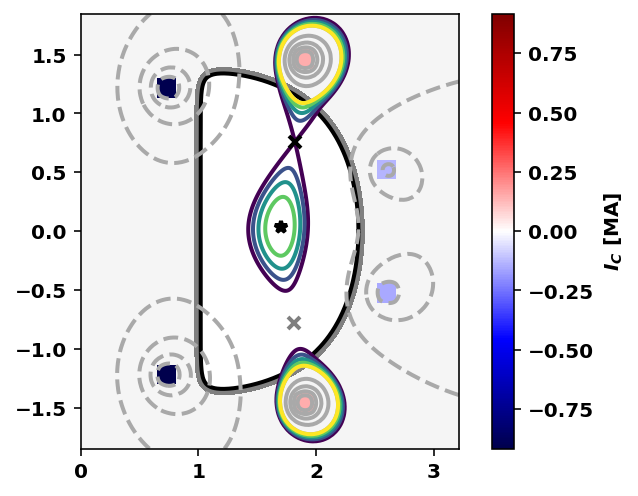

In [37]:
mygs.init_psi(r0=1.8, z0=-0.040, a=0.45, kappa=1.547, delta=-0.288)
#mygs.init_psi(1.82,0.0,0.56,1.7,0.2)
fig, ax = plt.subplots(1,1)
mygs.plot_machine(fig,ax,coil_colormap='seismic',coil_scale=1.E-6,coil_clabel=r'$I_C$ [MA]',coil_symmap=True)
mygs.plot_psi(fig,ax,plasma_nlevels=5,vacuum_nlevels=5)
mygs.plot_constraints(fig, ax)
# Print initial coil currents
print()
print("Coil Currents [kA]:")
coil_currents, _ = mygs.get_coil_currents()
for key in mygs.coil_sets:
    i = mygs.coil_sets[key]['id']
    if coil_currents[key] >= 0.0:
        proximity = coil_currents[key]*100/coil_bounds[key][1]
        near_limit = coil_bounds[key][1]
    else:
        proximity = coil_currents[key]*100/coil_bounds[key][0]
        near_limit = coil_bounds[key][0]
    print(' {0:10} {1:10.2F} ({2:7.2F}) [{3:6.2F}%]'.format(key+":",coil_currents[key]/1.E3,near_limit/1.E3,proximity))

In [38]:
err_flag = mygs.solve()
psi0 = mygs.get_psi(normalized=False)
coil_currents, _ = mygs.get_coil_currents()
print(err_flag)

Starting non-linear GS solver
     1  5.0027E+00 -1.8588E-01  5.3296E-03  1.6982E+00  3.5721E-02 -4.6814E+04
     2  1.2194E+00  4.4698E-02  8.2907E-04  1.7064E+00  2.7206E-02 -2.8151E+04
     3  8.5097E-01  7.2083E-02  2.5753E-04  1.7197E+00  1.4798E-02 -2.7849E+04
     4  7.2735E-01  8.3934E-02  1.6680E-04  1.7339E+00  1.5666E-03 -2.5289E+04
     5  6.9448E-01  9.2885E-02  2.0967E-04  1.7477E+00 -1.1523E-02 -2.2804E+04
     6  6.8638E-01  1.0002E-01  2.2888E-04  1.7611E+00 -2.4385E-02 -1.9798E+04
     7  6.8418E-01  1.0654E-01  2.3648E-04  1.7744E+00 -3.7107E-02 -1.6663E+04
     8  8.6671E-01  8.1973E-02  1.3870E-04  1.7770E+00 -3.9572E-02  1.8151E+02
     9  9.1253E-01  7.2250E-02  5.9400E-05  1.7775E+00 -4.0034E-02  2.7277E+02
    10  9.3282E-01  6.8402E-02  2.9875E-05  1.7776E+00 -4.0124E-02  8.5901E+01
    11  9.4316E-01  6.6664E-02  1.5829E-05  1.7776E+00 -4.0142E-02  1.0659E+02
    12  9.4829E-01  6.5827E-02  8.4546E-06  1.7776E+00 -4.0146E-02  1.3997E+02
    13  9.5075E-01  6.

---

### Compare free- and fixed-boundary cases
Plotting the LCFS of the fixed-boundary equilibrium over the free-boundary result shows good agreement, but minor differences as a finite coil set cannot, in general, exactly reproduce any arbitrary plasma shape.

Equilibrium Statistics:
  Topology                =   Diverted
  Toroidal Current [A]    =    4.9333E+05
  Current Centroid [m]    =    1.736 -0.052
  Magnetic Axis [m]       =    1.778 -0.040
  Elongation              =    1.581 (U:  1.424, L:  1.738)
  Triangularity           =   -0.302 (U: -0.242, L: -0.362)
  Plasma Volume [m^3]     =   14.500
  q_0, q_95               =    0.321  0.192
  Peak Pressure [Pa]      =    7.0168E+03
  Stored Energy [J]       =    5.2412E+04
  <Beta_pol> [%]          =   31.2213
  <Beta_tor> [%]          =   153.5178
  <Beta_n>   [%]          =   10.9324
  Diamagnetic flux [Wb]   =    8.6458E-02
  Toroidal flux [Wb]      =    1.7001E-01
  l_i                     =    0.8159


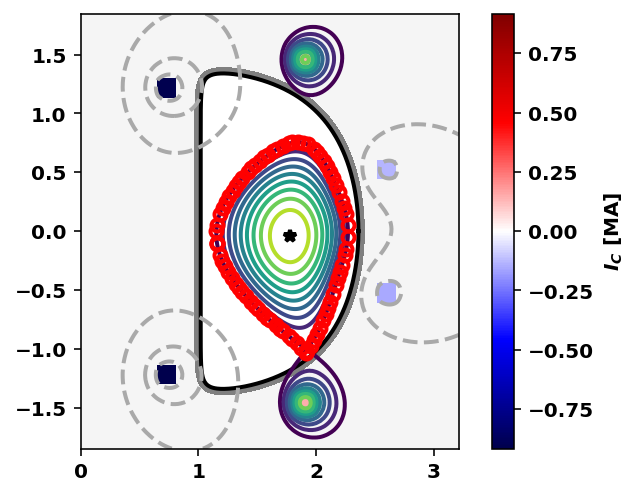

In [39]:
mygs.print_info()
# Plot flux surfaces and source LCFS
fig, ax = plt.subplots(1,1)
mygs.plot_machine(fig,ax,coil_colormap='seismic',coil_symmap=True,coil_scale=1.E-6,coil_clabel=r'$I_C$ [MA]')
mygs.plot_psi(fig,ax,xpoint_color=None,plasma_nlevels=10,vacuum_nlevels=4)
ax.plot(LCFS_contour[:,0],LCFS_contour[:,1],'ro',fillstyle='none')

## COMPARE TO ORIGINAL MESH ##


**** Loading OFT surface mesh

**** Generating surface grid level  1
  Generating boundary domain linkage
  Mesh statistics:
    Area         =  1.574E+01
    # of points  =    8911
    # of edges   =   26570
    # of cells   =   17660
    # of boundary points =     160
    # of boundary edges  =     160
    # of boundary cells  =     160
  Resolution statistics:
    hmin =  8.702E-04
    hrms =  4.833E-02
    hmax =  1.540E-01
  Surface grounded at vertex    1733


**** Creating Lagrange FE space
  Order  =    2
  Minlev =   -1

 Computing flux BC matrix 
 Inverting real matrix
   Time =    4.1900000000000001E-003


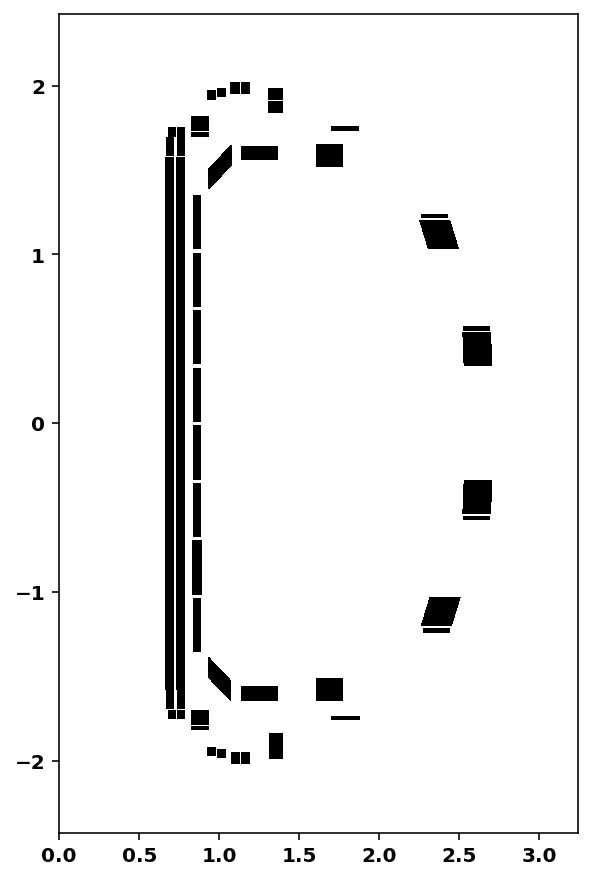

In [40]:
mygs2 = TokaMaker(myOFT)

mesh_pts,mesh_lc,mesh_reg,coil_dict,cond_dict = load_gs_mesh('DIII_D_orig/DIIID_mesh.h5')
mygs2.setup_mesh(mesh_pts, mesh_lc, mesh_reg)
mygs2.setup_regions(cond_dict=cond_dict,coil_dict=coil_dict)
mygs2.setup(order=2,F0=eqdsk['rcentr']*eqdsk['bcentr'])

fig, ax = plt.subplots(1,1,figsize=(4,6),constrained_layout=True)

mask_vals = np.ones((mygs2.np,))

for _, coil_reg in mygs2._coil_dict.items():
    mask_tmp = (mygs2.reg == coil_reg['reg_id'])
    ax.tricontourf(mygs2.r[:,0], mygs2.r[:,1], mygs2.lc[mask_tmp,:], mask_vals, colors='k', alpha=1)

Equilibrium Statistics:
  Topology                =   Diverted
  Toroidal Current [A]    =    4.9333E+05
  Current Centroid [m]    =    1.736 -0.052
  Magnetic Axis [m]       =    1.778 -0.040
  Elongation              =    1.581 (U:  1.424, L:  1.738)
  Triangularity           =   -0.302 (U: -0.242, L: -0.362)
  Plasma Volume [m^3]     =   14.500
  q_0, q_95               =    0.321  0.192
  Peak Pressure [Pa]      =    7.0168E+03
  Stored Energy [J]       =    5.2412E+04
  <Beta_pol> [%]          =   31.2213
  <Beta_tor> [%]          =   153.5178
  <Beta_n>   [%]          =   10.9324
  Diamagnetic flux [Wb]   =    8.6458E-02
  Toroidal flux [Wb]      =    1.7001E-01
  l_i                     =    0.8159


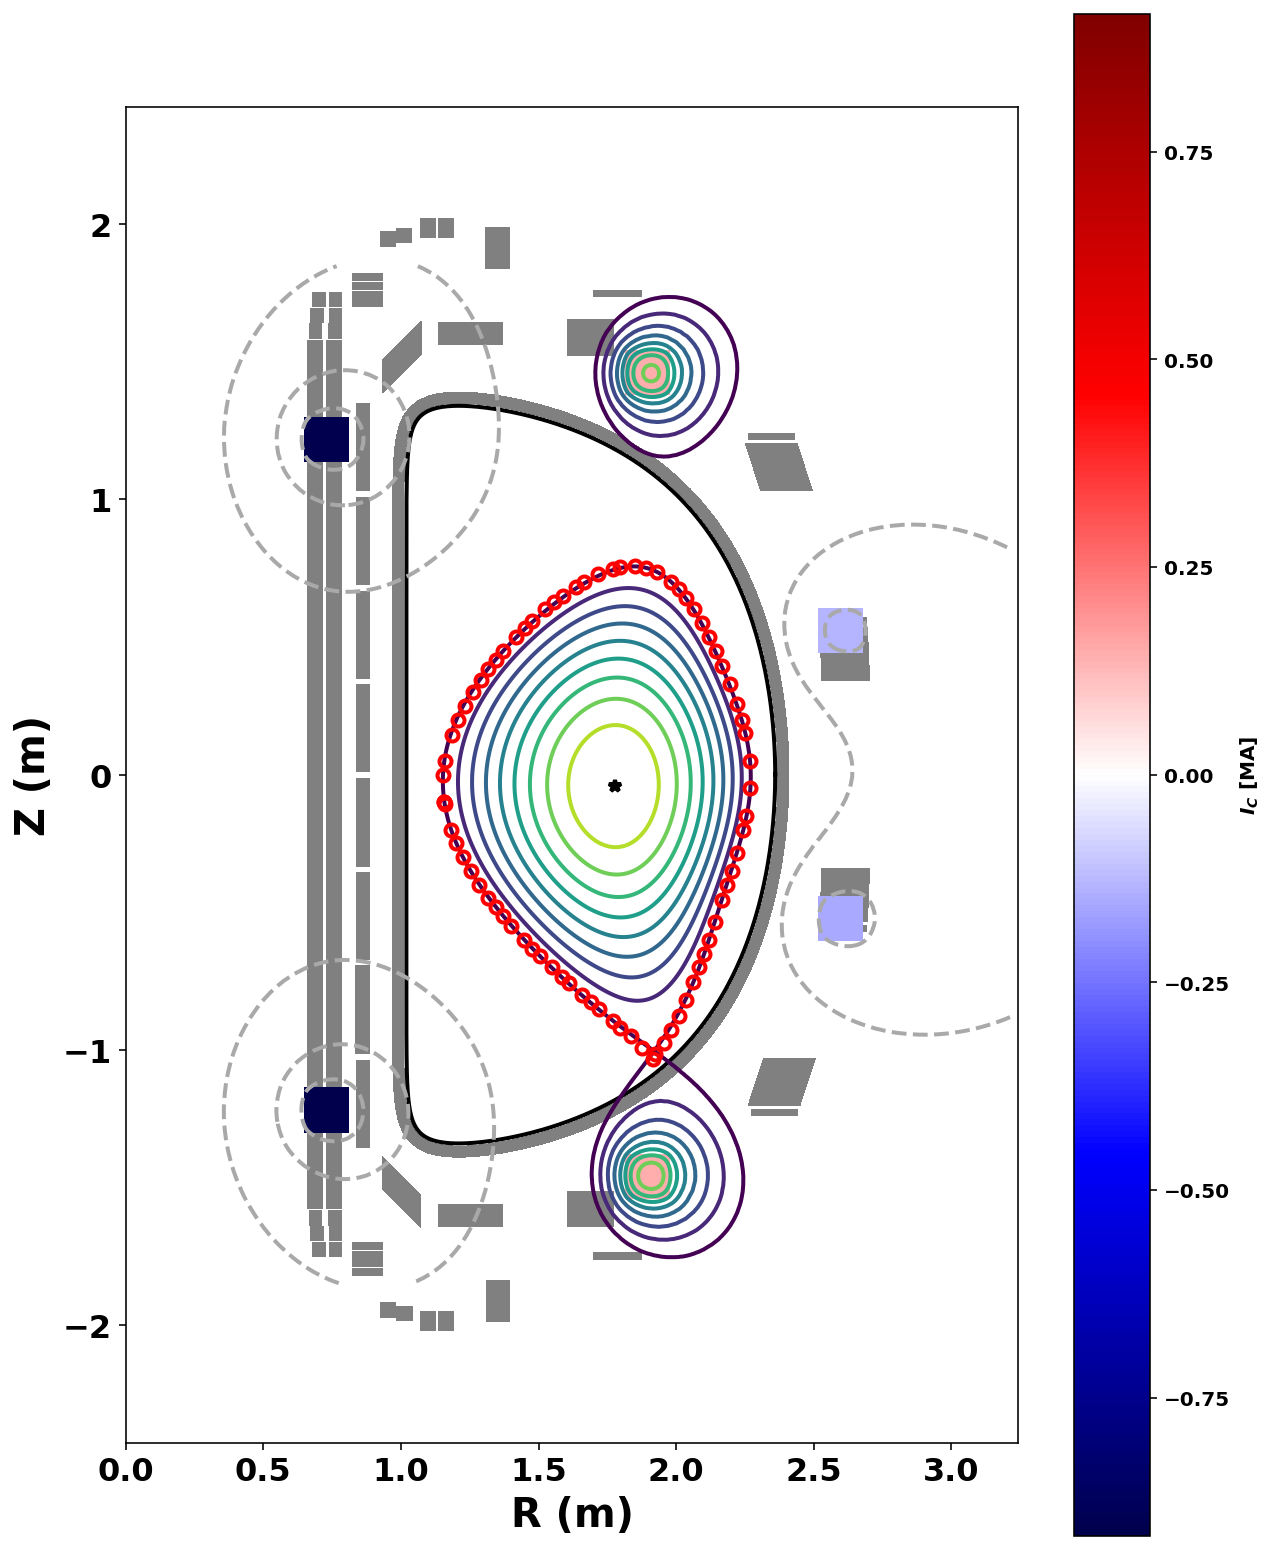

In [41]:
mygs.print_info()
# Plot flux surfaces and source LCFS
fig, ax = plt.subplots(1,1,figsize=(10,14))


mask_vals = np.ones((mygs2.np,))
for _, coil_reg in mygs2._coil_dict.items():
    mask_tmp = (mygs2.reg == coil_reg['reg_id'])
    ax.tricontourf(mygs2.r[:,0], mygs2.r[:,1], mygs2.lc[mask_tmp,:], mask_vals, colors='grey', alpha=1)
    
    

mygs.plot_machine(fig,ax,coil_colormap='seismic',coil_symmap=True,coil_scale=1.E-6,coil_clabel=r'$I_C$ [MA]', vacuum_color=None)
mygs.plot_psi(fig,ax,xpoint_color=None,plasma_nlevels=10,vacuum_nlevels=4)
ax.plot(LCFS_contour[:,0],LCFS_contour[:,1],'ro',fillstyle='none')

ax.set_xlabel('R (m)', fontsize=20)
ax.set_ylabel('Z (m)', fontsize=20)
ax.tick_params(labelsize=16)



### LETS ADD A SOLENOID CURRENT ###

In [42]:
scan_geom_DIIID_test['coils']['E0'] = {}
scan_geom_DIIID_test['coils']['E0']['pts'] = np.array([[0.64,-1],[0.8,-1],[0.8,1],[0.64,1]])
scan_geom_DIIID_test['coils']['E0']['nturns'] = 1.0

Assembling regions:
  # of unique points    = 2892
  # of unique segments  = 35
Generating mesh:
  # of points  = 81575
  # of cells   = 162920
  # of regions = 11


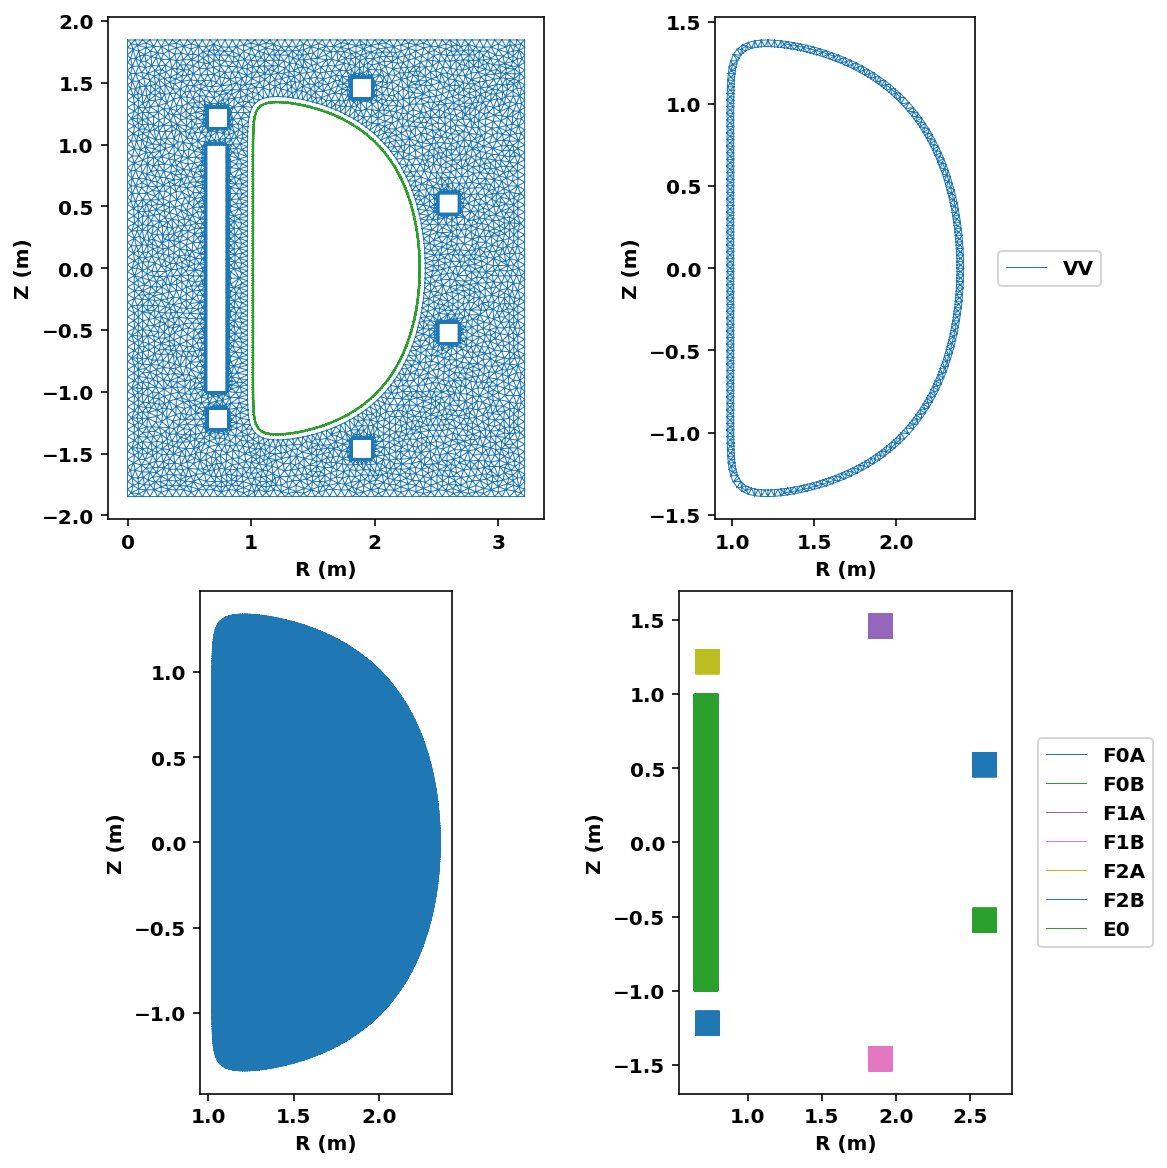

In [43]:
coil_dict_sol, cond_dict_sol = make_mesh(DIIID_geom, scan_geom_DIIID_test, savename = 'DIIID_mesh_scantest_withSolenoid.h5')

In [44]:
mygs.reset()
mesh_pts, mesh_lc, mesh_reg, coil_dict, cond_dict = load_gs_mesh('DIIID_mesh_scantest_withSolenoid.h5') # add this line to access mesh_pts etc
mygs.setup_mesh(mesh_pts,mesh_lc,mesh_reg)
mygs.setup_regions(cond_dict=cond_dict,coil_dict=coil_dict)
mygs.settings.free_boundary = True # free boundary
mygs.setup(order=2,F0=0.10752) # F0: vacuum F value


**** Loading OFT surface mesh

**** Generating surface grid level  1
  Generating boundary domain linkage
  Mesh statistics:
    Area         =  1.187E+01
    # of points  =   81575
    # of edges   =  244494
    # of cells   =  162920
    # of boundary points =     228
    # of boundary edges  =     228
    # of boundary cells  =     228
  Resolution statistics:
    hmin =  3.102E-03
    hrms =  1.373E-02
    hmax =  9.006E-02
  Surface grounded at vertex    2862


**** Creating Lagrange FE space
  Order  =    2
  Minlev =   -1

 Computing flux BC matrix 
 Inverting real matrix
   Time =    1.0917000000000000E-002


In [45]:
mygs.set_coil_vsc({'F0A': 1.0, 'F0B': -1.0})

In [46]:
Ip_target = eqdsk['ip']
R0_target = fixed_mag_axis[0].item()
Z0 = fixed_mag_axis[1].item()
mygs.set_targets(Ip=Ip_target,R0=R0_target,V0=Z0)

### Define hard limits on coil currents

coil_bounds = {key: [-6.E8, 6.E8] for key in mygs.coil_sets}
mygs.set_coil_bounds(coil_bounds)

In [47]:
isoflux_pts = eqdsk['rzout'].copy()
mygs.set_isoflux(isoflux_pts)

In [48]:
## Same regmat for all (might be ambitious)
def set_regularization(gs_obj, solenoid_target):
    regularization_terms = []
    for name, coil in mygs.coil_sets.items():
        if name.find('E0') >= 0: # We will set everything for upper coils
            regularization_terms.append(mygs.coil_reg_term({name: 1.0},target=solenoid_target,weight=1.E4))
        else:
            regularization_terms.append(mygs.coil_reg_term({name: 1.0},target=0.0,weight=1.E-2))
    # Pass regularization terms to TokaMaker
    gs_obj.set_coil_reg(reg_terms=regularization_terms)

In [49]:
### Iterate through various solenoid currents 

coil_names = list(mygs.coil_sets.keys())

solenoid_targets = np.linspace(-1e6, 1e6, 11)#21)

showplots = False

coil_currents = np.zeros((len(solenoid_targets), len(coil_names)))

for i, solenoid_target in enumerate(solenoid_targets):
    set_regularization(mygs, solenoid_target)
    mygs.init_psi(r0=1.8, z0=-0.040, a=0.45, kappa=1.547, delta=-0.288)
    err_flag = mygs.solve()

    currents, currents_reg = mygs.get_coil_currents()
    coil_currents[i] = np.array([currents[name] for name in coil_names])

Starting non-linear GS solver


     1  1.1302E+00  2.3806E-03  8.4165E-04  1.7643E+00 -5.0335E-02  2.5278E+04
     2  7.7720E-01  6.6905E-02  2.2993E-04  1.7744E+00 -4.4013E-02  1.6043E+04
     3  7.3127E-01  8.0408E-02  1.3901E-04  1.7806E+00 -4.1289E-02  1.4282E+04
     4  7.5595E-01  8.0487E-02  9.2843E-05  1.7826E+00 -4.0141E-02  1.3607E+04
     5  7.9975E-01  7.6207E-02  5.9587E-05  1.7822E+00 -3.9689E-02  1.3258E+04
     6  8.4604E-01  7.0524E-02  3.7248E-05  1.7807E+00 -3.9528E-02  1.3045E+04
     7  8.9102E-01  6.4328E-02  2.5073E-05  1.7788E+00 -3.9482E-02  1.2900E+04
     8  9.0417E-01  6.2960E-02  1.5648E-05  1.7778E+00 -3.9471E-02  1.2823E+04
     9  9.0880E-01  6.2726E-02  9.7215E-06  1.7773E+00 -3.9470E-02  1.2779E+04
    10  9.1083E-01  6.2733E-02  6.2072E-06  1.7772E+00 -3.9471E-02  1.2753E+04
    11  9.1191E-01  6.2775E-02  4.0091E-06  1.7771E+00 -3.9472E-02  1.2736E+04
    12  9.1253E-01  6.2810E-02  2.5835E-06  1.7771E+00 -3.9473E-02  1.2726E+04
    13  9.1291E-01  6.2834E-02  1.6533E-06  1.7771E+

/var/folders/05/5bk04kj15rg64s4vd1hd6r0m0000gn/T/ipykernel_16834/1728513393.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(coil_names, fontsize=20)


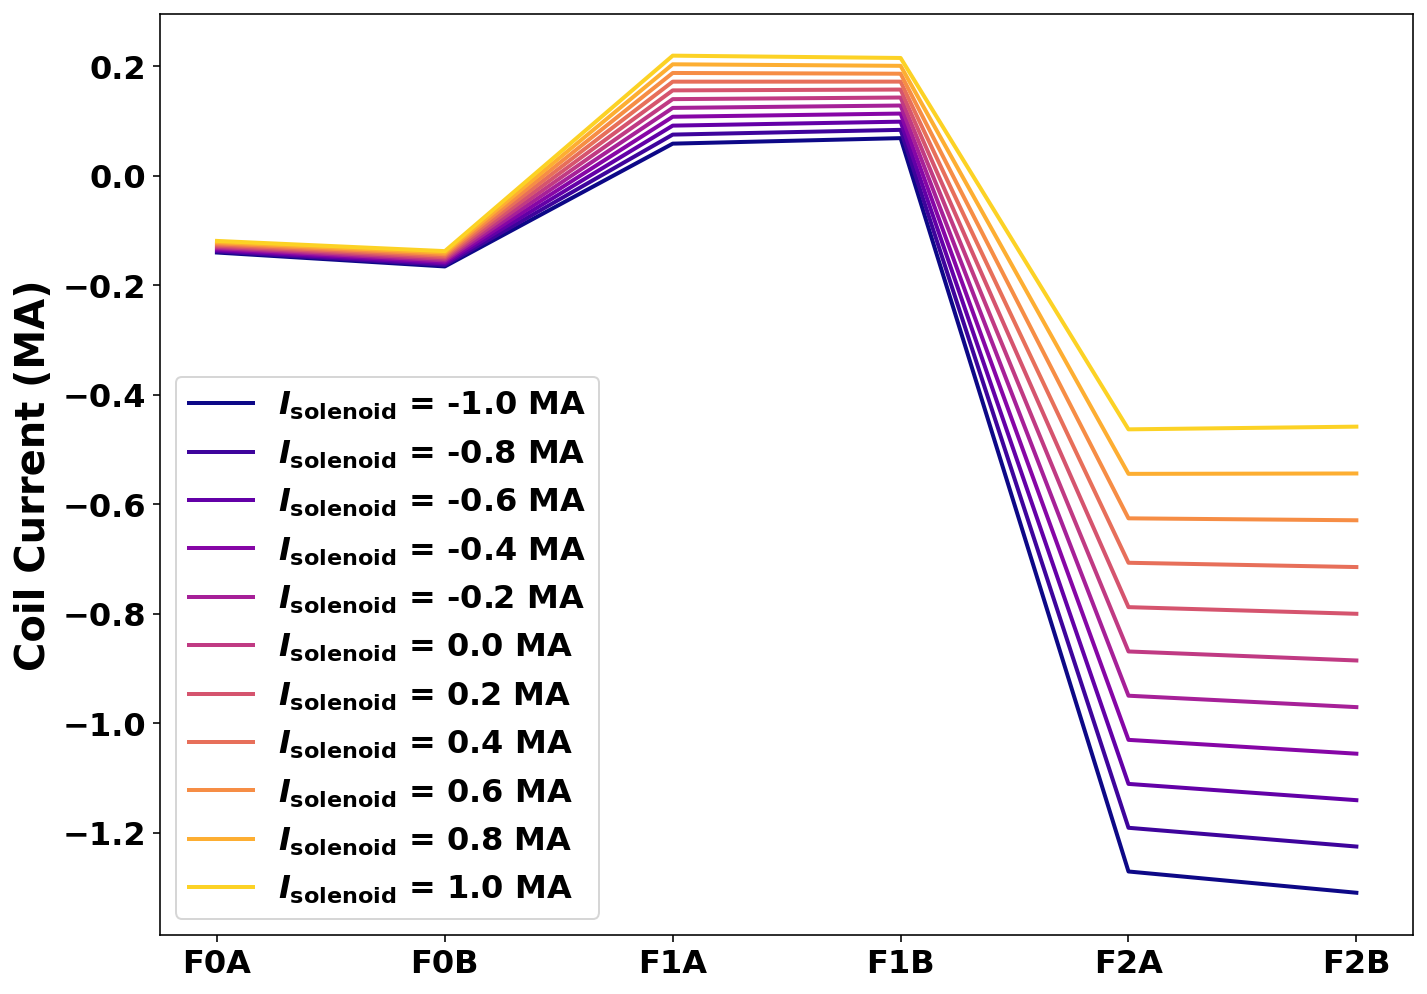

In [50]:
cmap = plt.get_cmap('plasma')

## Plot the coil currents

fig, ax = plt.subplots(1,1, figsize=(10,7))
for i, solenoid_target in enumerate(solenoid_targets):
    ax.plot(coil_names[:-1], coil_currents[i][:-1]/1e6, c=cmap(i/len(solenoid_targets)), label=r'$I_\mathrm{solenoid}$ = '+f'{solenoid_target/1e6} MA', lw=2)

ax.set_ylabel('Coil Current (MA)',fontsize=20)
ax.set_xticklabels(coil_names, fontsize=20)
ax.tick_params(labelsize=16)

ax.legend(loc=3,fontsize=16)

plt.tight_layout()
plt.show()

Equilibrium Statistics:
  Topology                =   Diverted
  Toroidal Current [A]    =    4.9330E+05
  Current Centroid [m]    =    1.736 -0.050
  Magnetic Axis [m]       =    1.777 -0.040
  Elongation              =    1.571 (U:  1.427, L:  1.716)
  Triangularity           =   -0.295 (U: -0.242, L: -0.349)
  Plasma Volume [m^3]     =   14.369
  q_0, q_95               =    0.321  0.189
  Peak Pressure [Pa]      =    7.0654E+03
  Stored Energy [J]       =    5.2494E+04
  <Beta_pol> [%]          =   30.8278
  <Beta_tor> [%]          =   155.2596
  <Beta_n>   [%]          =   11.0044
  Diamagnetic flux [Wb]   =    8.6567E-02
  Toroidal flux [Wb]      =    1.6946E-01
  l_i                     =    0.8069


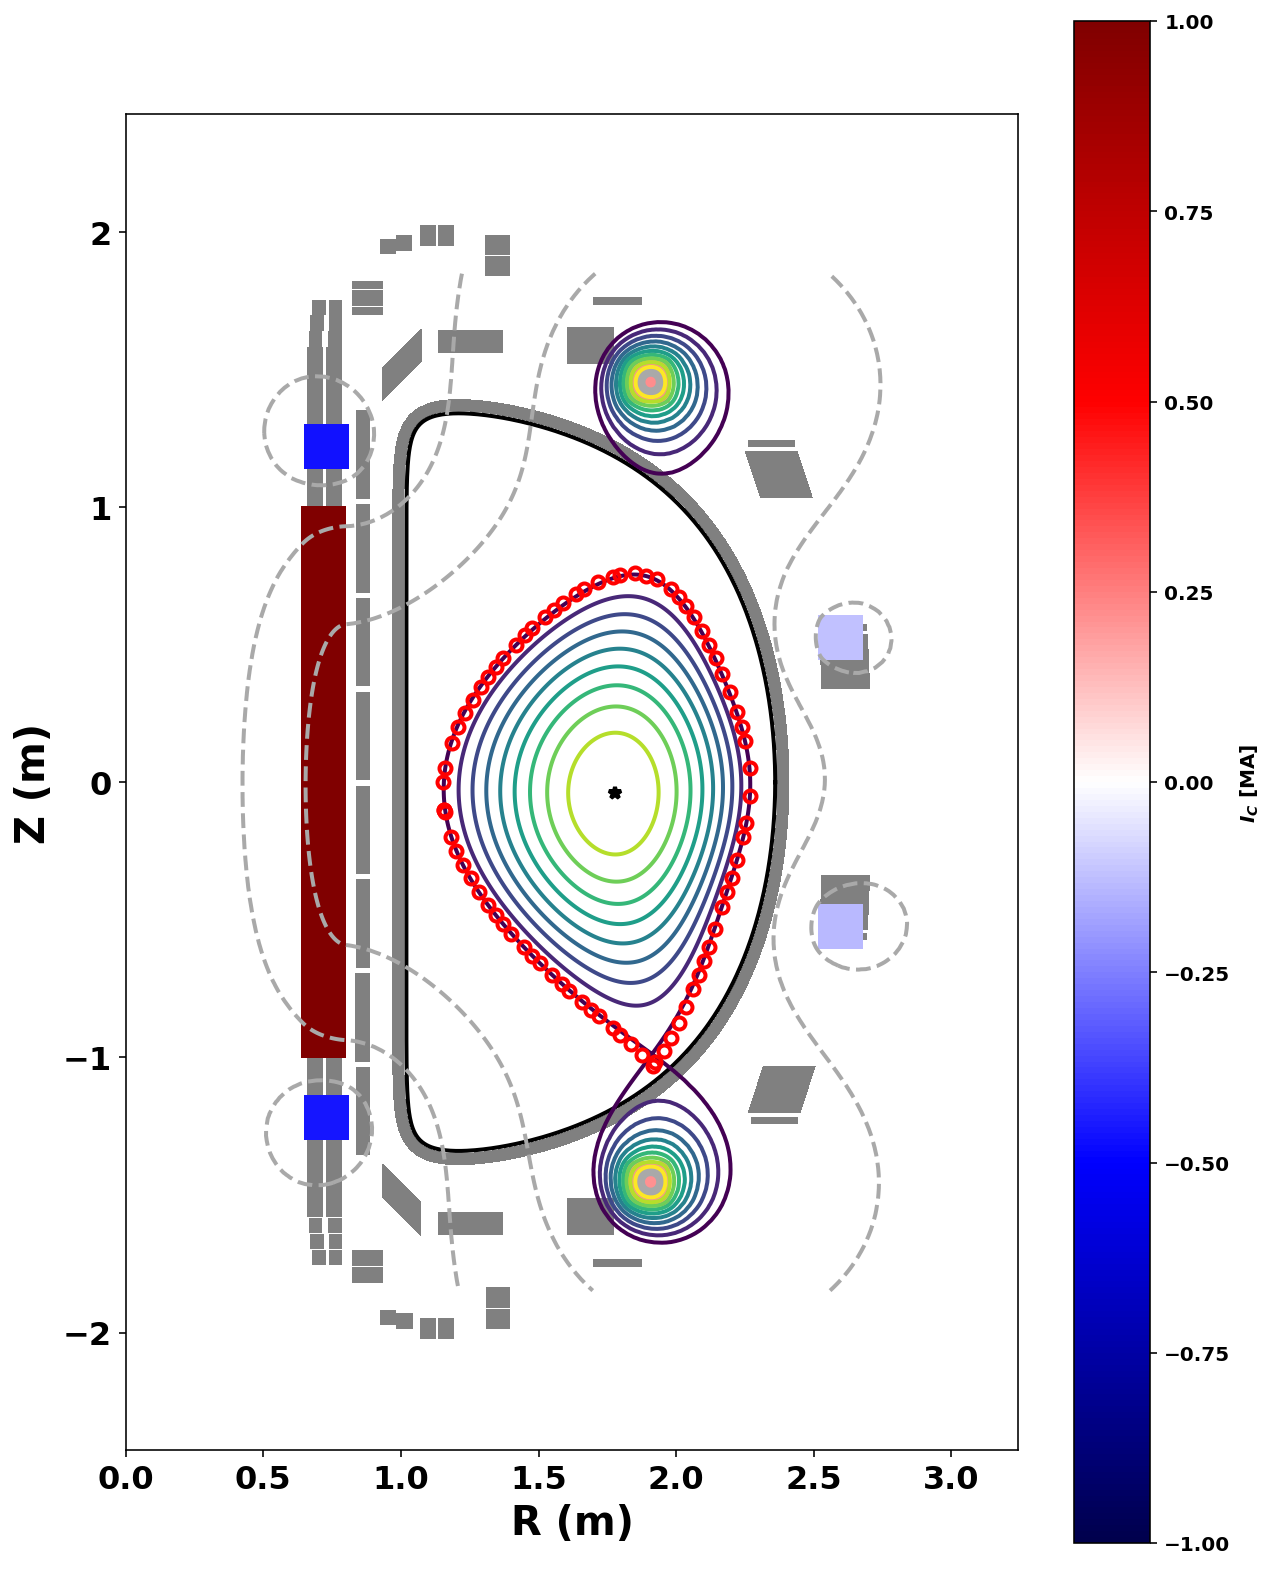

In [51]:
## Plot the final solution just for kicks

mygs.print_info()
# Plot flux surfaces and source LCFS
fig, ax = plt.subplots(1,1,figsize=(10,14))


mask_vals = np.ones((mygs2.np,))
for _, coil_reg in mygs2._coil_dict.items():
    mask_tmp = (mygs2.reg == coil_reg['reg_id'])
    ax.tricontourf(mygs2.r[:,0], mygs2.r[:,1], mygs2.lc[mask_tmp,:], mask_vals, colors='grey', alpha=1)
    
    

mygs.plot_machine(fig,ax,coil_colormap='seismic',coil_symmap=True,coil_scale=1.E-6,coil_clabel=r'$I_C$ [MA]', vacuum_color=None)
mygs.plot_psi(fig,ax,xpoint_color=None,plasma_nlevels=10,vacuum_nlevels=4)
ax.plot(LCFS_contour[:,0],LCFS_contour[:,1],'ro',fillstyle='none')

ax.set_xlabel('R (m)', fontsize=20)
ax.set_ylabel('Z (m)', fontsize=20)
ax.tick_params(labelsize=16)

